In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  34220.5 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 43 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [5]:
using ProgressMeter
using ColorSchemes
using JLD2


In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Testing v1
plot theory lengthscales as key bit and then put on top a couple of series from PDE final state solutions

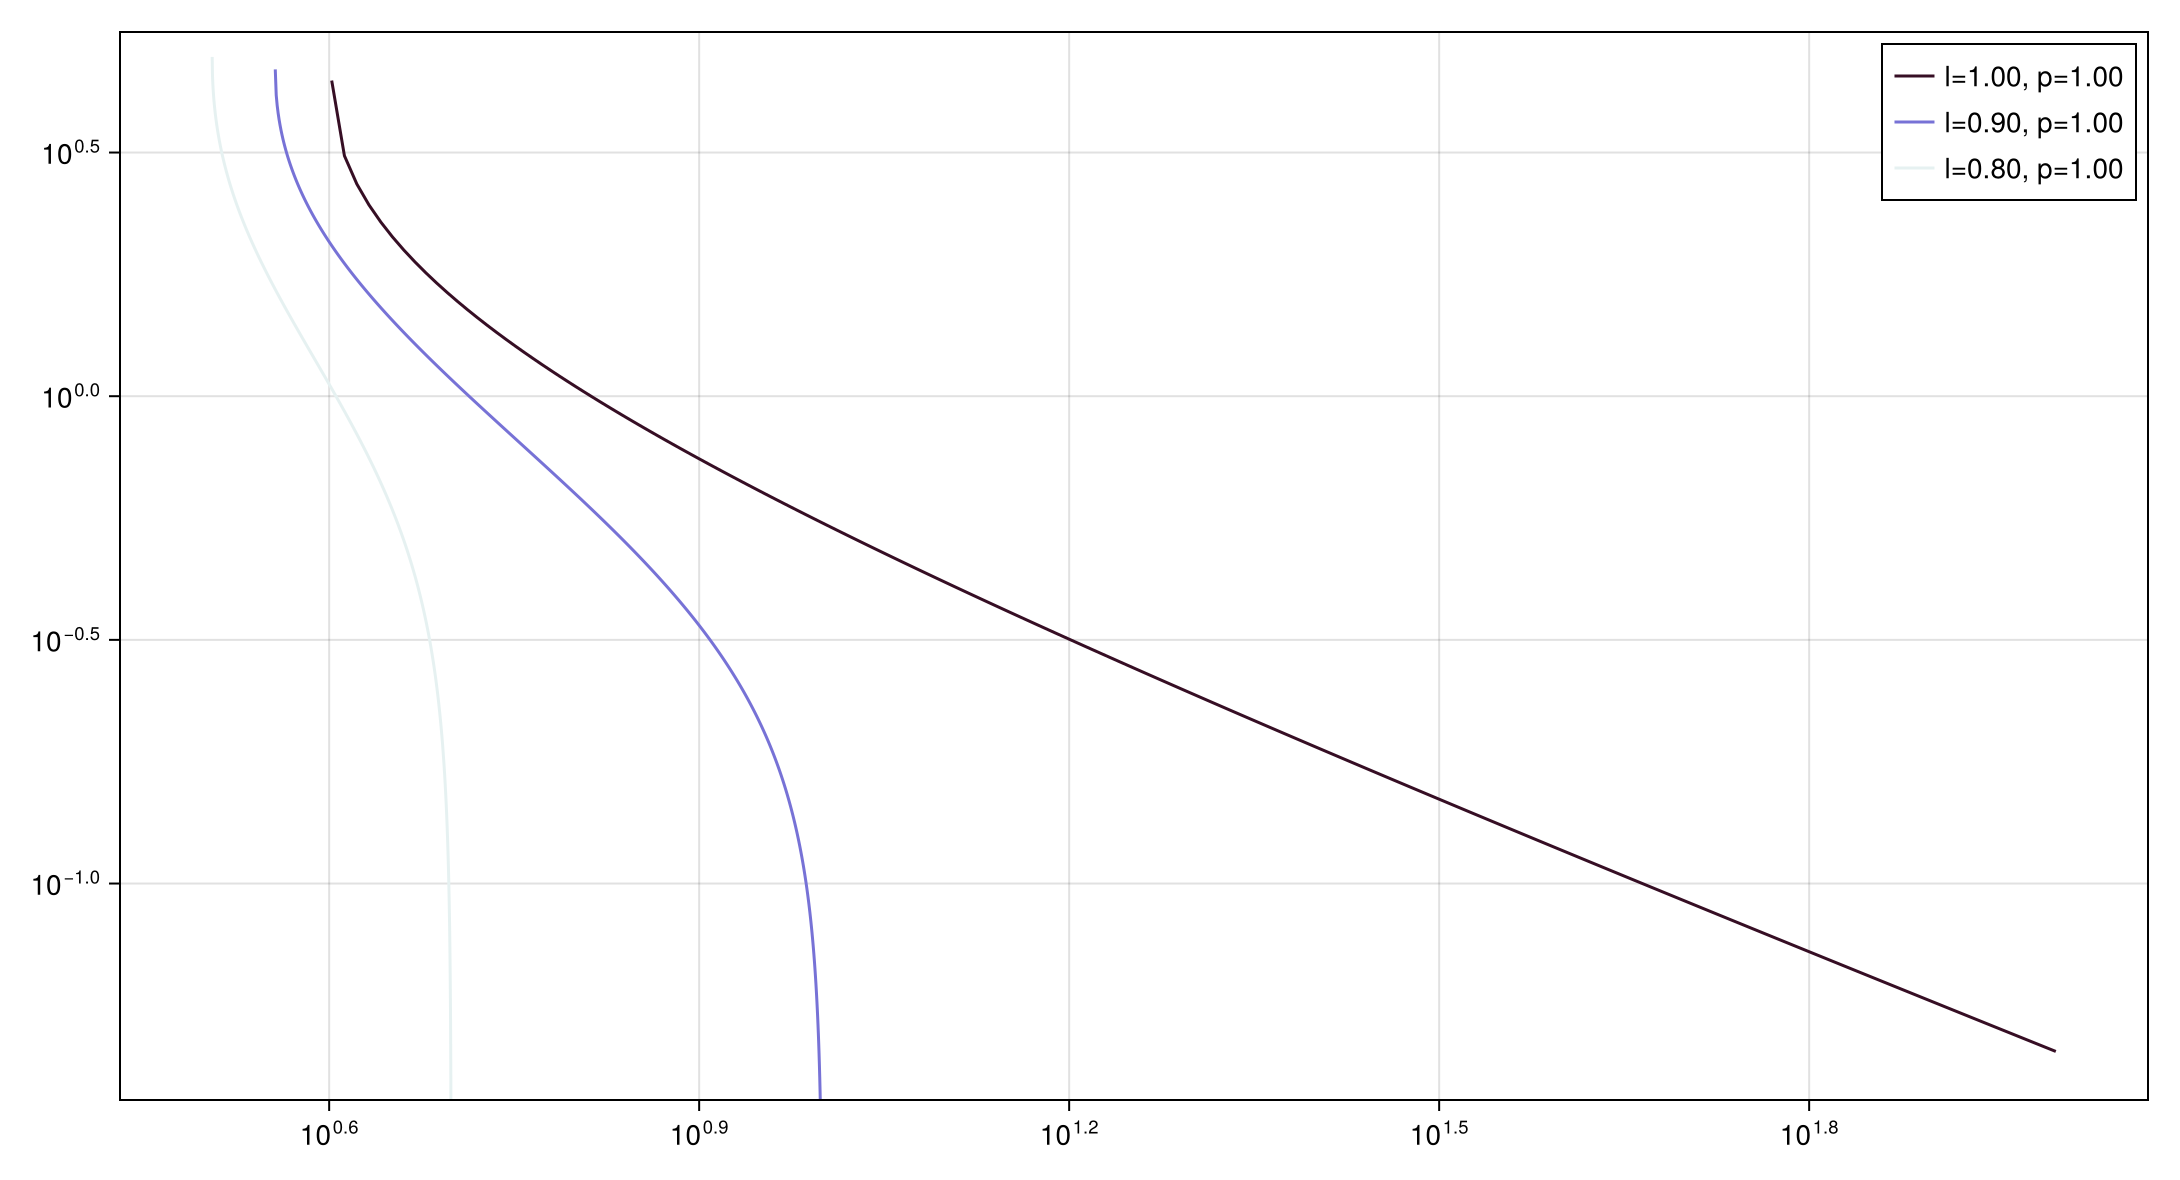

In [31]:
lps = [
    (1., 1.),
    (0.9, 1.),
    (0.8, 1.),
    # (1., 0.5),
    # (0.9, 0.5),
    # (0.8, 0.5),
    # (1., 0.1),
    # (0.8, 0.1),
    # (0.5, 0.1),
]

lmin, lmax = extrema(getindex.(lps, 1))
ldelta = lmax - lmin
pmin, pmax = extrema(getindex.(lps, 2))
pdelta = pmax - pmin

fig = Figure(;
    size=(double_col_width * 1.6, 1.4 * double_col_width / golden_ratio)
)
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
)

for (l, p) in lps
    betas = MinimalModelV2.fr2_instab_beta_range(l, p, 1000; betamax=100.)
    km2s = MinimalModelV2.fr2_km2.(betas, l, p, 1.)
    Lms = MinimalModelV2.ksquared_to_L.(km2s)
    
    lines!(ax, betas, Lms;
        label=(@sprintf "l=%.2f, p=%.2f" l p),
        linestyle=p == 1 ? :solid : :dash,
        color=get(ColorSchemes.dense, (l - lmin) / ldelta)
    )
end

axislegend(ax)

fig

In [32]:
f["ls"]

30-element Vector{Float64}:
 0.010000000000000009
 0.013677718551906581
 0.018682474041373354
 0.025471206742066488
 0.03463971321706649
 0.046949480891762096
 0.06334666692783586
 0.08496008499463492
 0.11305773103250916
 0.1489352588752726
 0.19371150038566554
 0.24802624416423247
 0.31168317138069135
 ⋮
 0.7519737558357673
 0.8062884996143342
 0.8510647411247272
 0.8869422689674907
 0.915039915005365
 0.9366533330721641
 0.9530505191082378
 0.9653602867829335
 0.9745287932579334
 0.9813175259586266
 0.9863222814480934
 0.99

In [6]:
f = jldopen("../../cluster_env/runs/mm_v2_explike/v3_base1.jld2")

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/cluster_env/runs/mm_v2_explike/v3_base1.jld2 (read-only)
 ├─🔢 logKs
 ├─🔢 ls
 ├─🔢 T
 ├─🔢 m
 ├─🔢 c
 ├─🔢 DN
 ├─🔢 DI
 ├─🔢 DR
 ├─🔢 N0
 └─ ⋯ (13 more entries)

In [18]:
xx = get_peaks(f);
typeof(xx)

@NamedTuple{full_peaks::Matrix{@NamedTuple{indices::Vector{Int64}, heights::Vector{Float64}, data::Vector{Float64}, proms::Vector{Float64}}}, numpeaks::Matrix{Int64}, avg_pkh::Matrix{Float64}, avg_pkw::Matrix{Union{Missing, Float64}}, avg_pkp::Matrix{Union{Missing, Float64}}, avg_pksp::Matrix{Union{Missing, Float64}}}

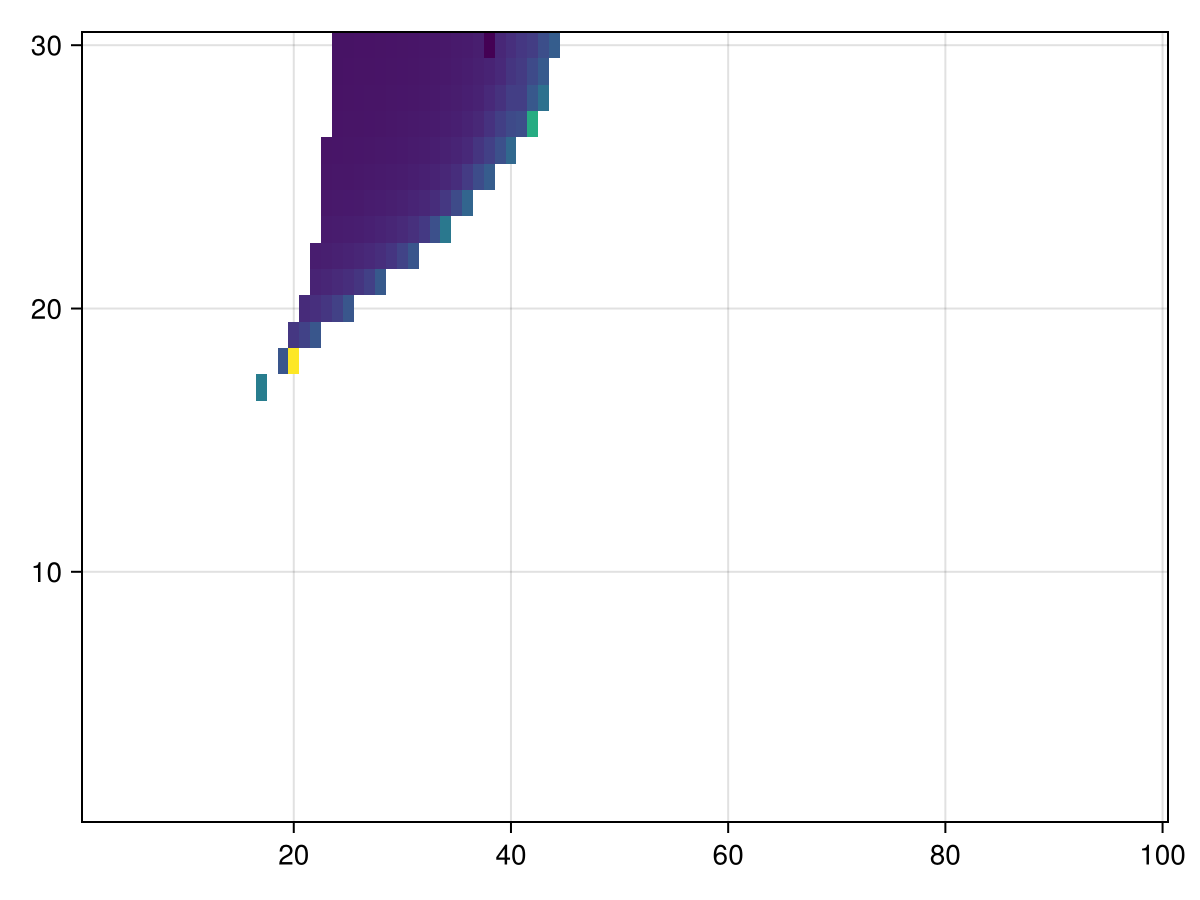

In [23]:
heatmap(xx.avg_pkw)

In [7]:
using Peaks

In [8]:
function get_peaks(fss, dx)
    full_peaks = map(fss) do fs
        all_pks = findmaxima(fs[1, :])
        peakproms(all_pks; min=0.1)
    end
    numpeaks = map(full_peaks) do pks
        length(pks.indices)
    end
    avg_pkh = map(full_peaks) do pks
        mean(pks.heights)
    end
    avg_pkw = map(full_peaks) do pks
        if length(pks.indices) > 0
            mean(peakwidths(pks).widths) * dx
        else
            missing
        end
    end
    avg_pkp = map(full_peaks) do pks
        if length(pks.indices) > 0
            mean(peakproms(pks).proms)
        else
            missing
        end
    end
    avg_pksp = map(full_peaks) do pks
        if length(pks.indices) > 0
            spacings = pks.indices[2:end] .- pks.indices[1:end-1]
            push!(spacings, length(pks.data) + pks.indices[1] - pks.indices[end]) # periodic boundary
            mean(spacings) * dx
        else
            missing
        end
    end
    (; full_peaks, numpeaks, avg_pkh, avg_pkw, avg_pkp, avg_pksp)
end
function get_peaks(f)
    get_peaks(f["final_states"], f["L"] / f["sN"])
end


get_peaks (generic function with 2 methods)